In [1]:
# load the necessary packages
library("tidyverse")
library("lme4")
library("emmeans")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
# load the data
data <- read.csv('df_ampc_vs_loss.csv')

In [3]:
data$upper_bound <- as.factor(data$upper_bound)

In [4]:
model = lmer(loss ~ 1 + ampc*v1_unit+upper_bound + (1+ampc|dlgn_unit), data = data)

In [5]:
summary(model)

Linear mixed model fit by REML ['lmerMod']
Formula: loss ~ 1 + ampc * v1_unit + upper_bound + (1 + ampc | dlgn_unit)
   Data: data

REML criterion at convergence: -101680.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9260 -0.6104 -0.2128  0.3994  8.3352 

Random effects:
 Groups    Name        Variance  Std.Dev. Corr 
 dlgn_unit (Intercept) 2.977e-05 0.005456      
           ampc        2.717e-02 0.164832 -0.56
 Residual              2.049e-04 0.014315      
Number of obs: 18000, groups:  dlgn_unit, 6

Fixed effects:
                 Estimate Std. Error t value
(Intercept)     0.0599193  0.0071247   8.410
ampc            0.9733326  0.2154610   4.517
v1_unit         0.0077323  0.0044977   1.719
upper_bound0.2  0.0060272  0.0002821  21.369
upper_bound0.3  0.0150793  0.0003424  44.046
ampc:v1_unit   -0.3916954  0.1359480  -2.881

Correlation of Fixed Effects:
            (Intr) ampc   v1_unt up_0.2 up_0.3
ampc        -0.565                            
v1_unit     -0.9

In [6]:
## Test the significance of each effect

effect_significance = data.frame(joint_tests(model))
effect_significance

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,model.term,df1,df2,F.ratio,Chisq,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ampc,1,Inf,31.819,31.819,1.692600e-08
3,v1_unit,1,Inf,1.874,1.874,1.710094e-01
4,upper_bound,2,Inf,988.696,1977.392,0.000000e+00
2,ampc:v1_unit,1,Inf,8.301,8.301,3.961459e-03


In [7]:
## get the predicted intercept for each group

intercept_pred = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans %>% data.frame()
intercept_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampc,emmean,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.1,0.03484837,0.08792074,0.003062868,Inf,0.08191763,0.09392385
2,2,0.1,0.03484837,0.08200310,0.003065737,Inf,0.07599436,0.08801183
3,1,0.2,0.03484837,0.09394795,0.003059672,Inf,0.08795111,0.09994480
4,2,0.2,0.03484837,0.08803031,0.003061410,Inf,0.08203005,0.09403056
5,1,0.3,0.03484837,0.10300004,0.003060397,Inf,0.09700177,0.10899831
6,2,0.3,0.03484837,0.09708239,0.003060926,Inf,0.09108309,0.10308170


In [8]:
## Get intercept contrasts
intercept_contrasts = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans  %>% pairs()  %>% data.frame()

intercept_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,contrast,ampc,estimate,SE,df,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.1,0.03484837,0.0059176446,0.0043227065,Inf,1.36896746,7.457290e-01
2,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.2,0.03484837,-0.0060272115,0.0002820585,Inf,-21.36865928,0.000000e+00
3,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.2,0.03484837,-0.0001095669,0.0043310977,Inf,-0.02529772,1.000000e+00
4,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.3,0.03484837,-0.0150792992,0.0003423521,Inf,-44.04617606,0.000000e+00
5,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.3,0.03484837,-0.0091616547,0.0043345878,Inf,-2.11361610,2.800596e-01
6,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.2,0.03484837,-0.0119448561,0.0043327001,Inf,-2.75690810,6.460129e-02
7,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.2,0.03484837,-0.0060272115,0.0002820585,Inf,-21.36865928,0.000000e+00
8,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.3,0.03484837,-0.0209969438,0.0043378960,Inf,-4.84035208,1.915455e-05
9,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.3,0.03484837,-0.0150792992,0.0003423521,Inf,-44.04617606,0.000000e+00


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



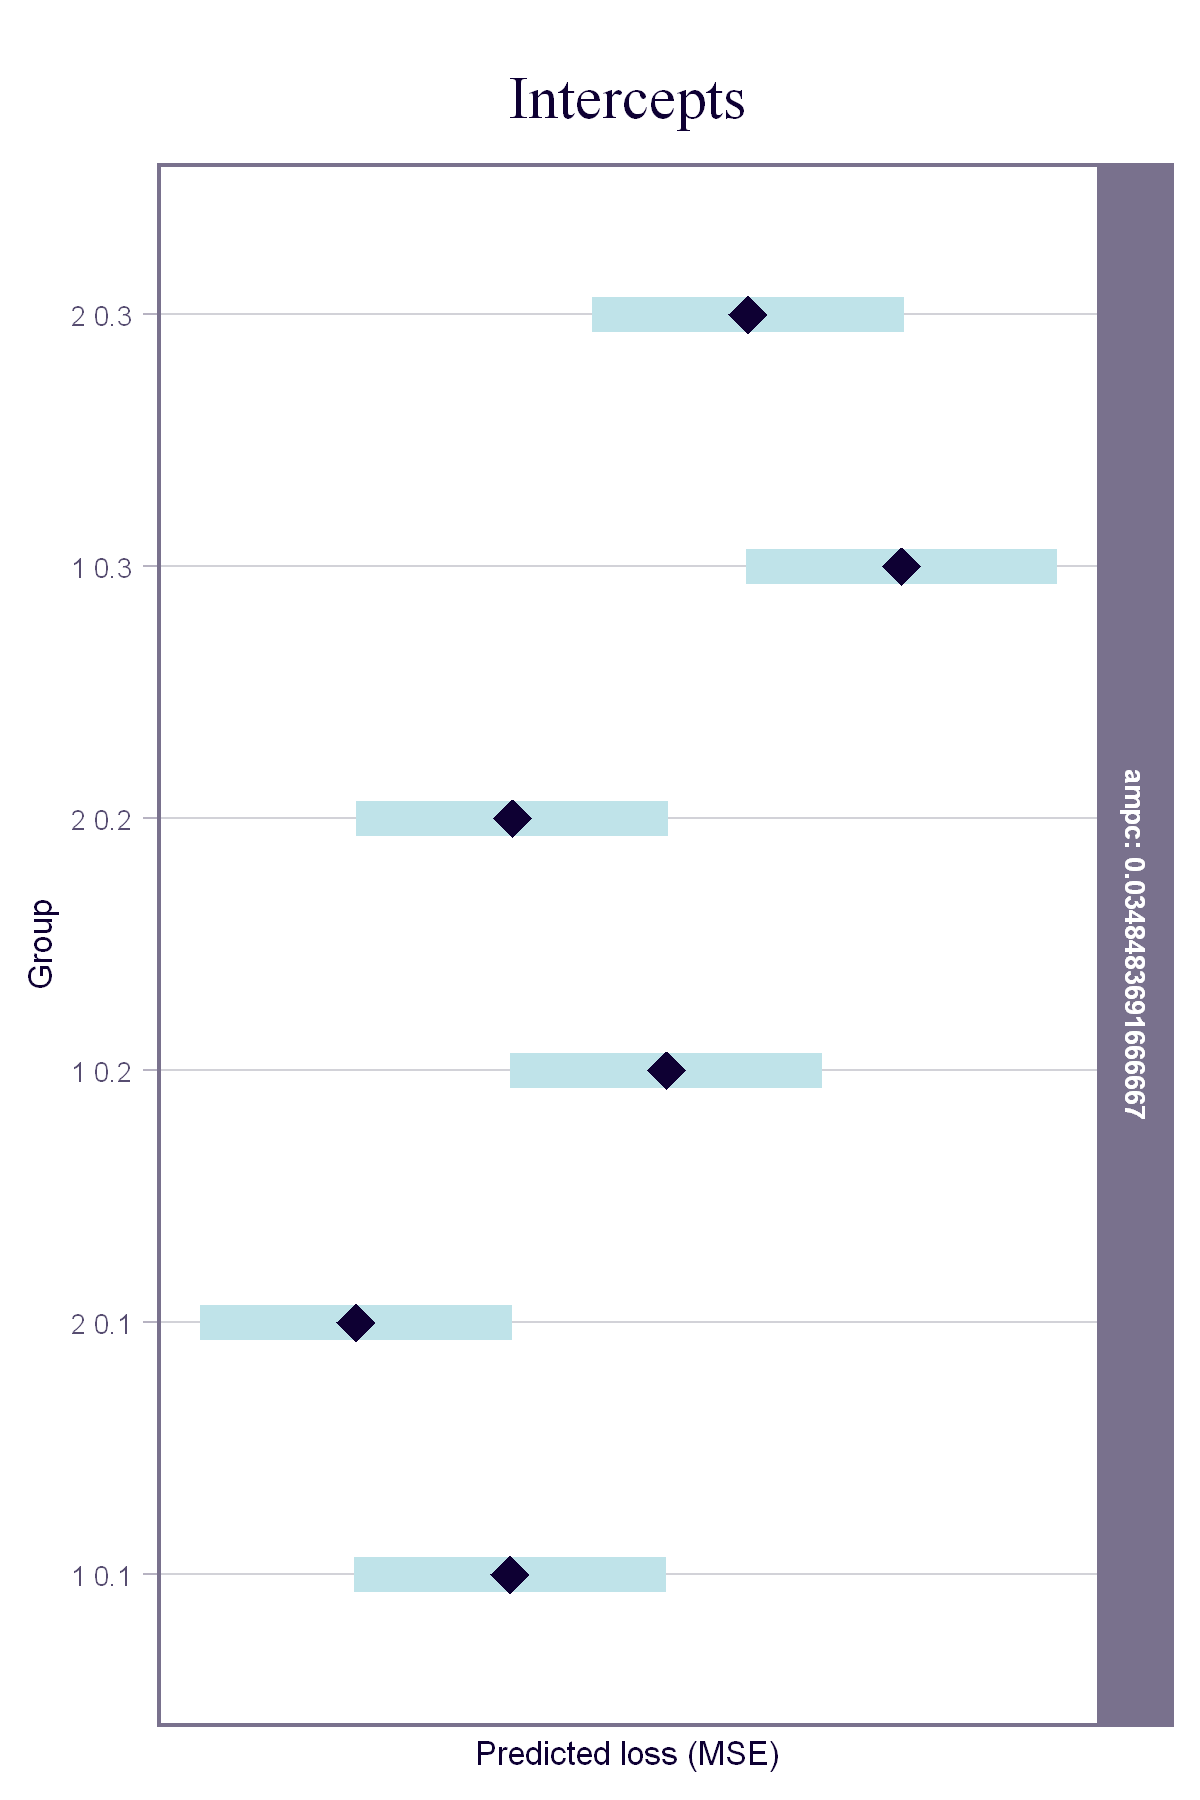

In [9]:
# adjust figure attributes:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emmeans(
    model, 
    pairwise ~ v1_unit+upper_bound|ampc,
    at = list(ampw = c(0.0)) 
)$emmeans %>% plot() +
    labs(
        x = 'Predicted loss (MSE)',
        y = 'Group',
        title = 'Intercepts'
    ) + 
    geom_point(size=0.05) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [10]:
## get the predicted slope for each group

slope_pred = emtrends(
    model, 
    var = 'ampc', 
    specs = c('v1_unit', 'upper_bound') 
) %>% data.frame()
slope_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampc.trend,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.1,0.5816372,0.09670533,Inf,0.392098239,0.7711762
2,2,0.1,0.1899418,0.09614637,Inf,0.001498427,0.3783853
3,1,0.2,0.5816372,0.09670533,Inf,0.392098239,0.7711762
4,2,0.2,0.1899418,0.09614637,Inf,0.001498427,0.3783853
5,1,0.3,0.5816372,0.09670533,Inf,0.392098239,0.7711762
6,2,0.3,0.1899418,0.09614637,Inf,0.001498427,0.3783853


In [11]:
## Get slope contrasts

slope_contrasts = emtrends(
    model, 
    var = 'ampc',
    specs = c('v1_unit', 'upper_bound') 
)  %>% pairs()  %>% data.frame()
slope_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.1,0.3916954,0.135948,Inf,2.881215,0.02952627
2,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.2,0.0000000,0.000000,Inf,NaN,NaN
3,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.2,0.3916954,0.135948,Inf,2.881215,0.02952627
4,v1_unit1 upper_bound0.1 - v1_unit1 upper_bound0.3,0.0000000,0.000000,Inf,NaN,NaN
5,v1_unit1 upper_bound0.1 - v1_unit2 upper_bound0.3,0.3916954,0.135948,Inf,2.881215,0.02952627
6,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.2,-0.3916954,0.135948,Inf,-2.881215,0.02952627
7,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.2,0.0000000,0.000000,Inf,NaN,NaN
8,v1_unit2 upper_bound0.1 - v1_unit1 upper_bound0.3,-0.3916954,0.135948,Inf,-2.881215,0.02952627
9,v1_unit2 upper_bound0.1 - v1_unit2 upper_bound0.3,0.0000000,0.000000,Inf,NaN,NaN


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



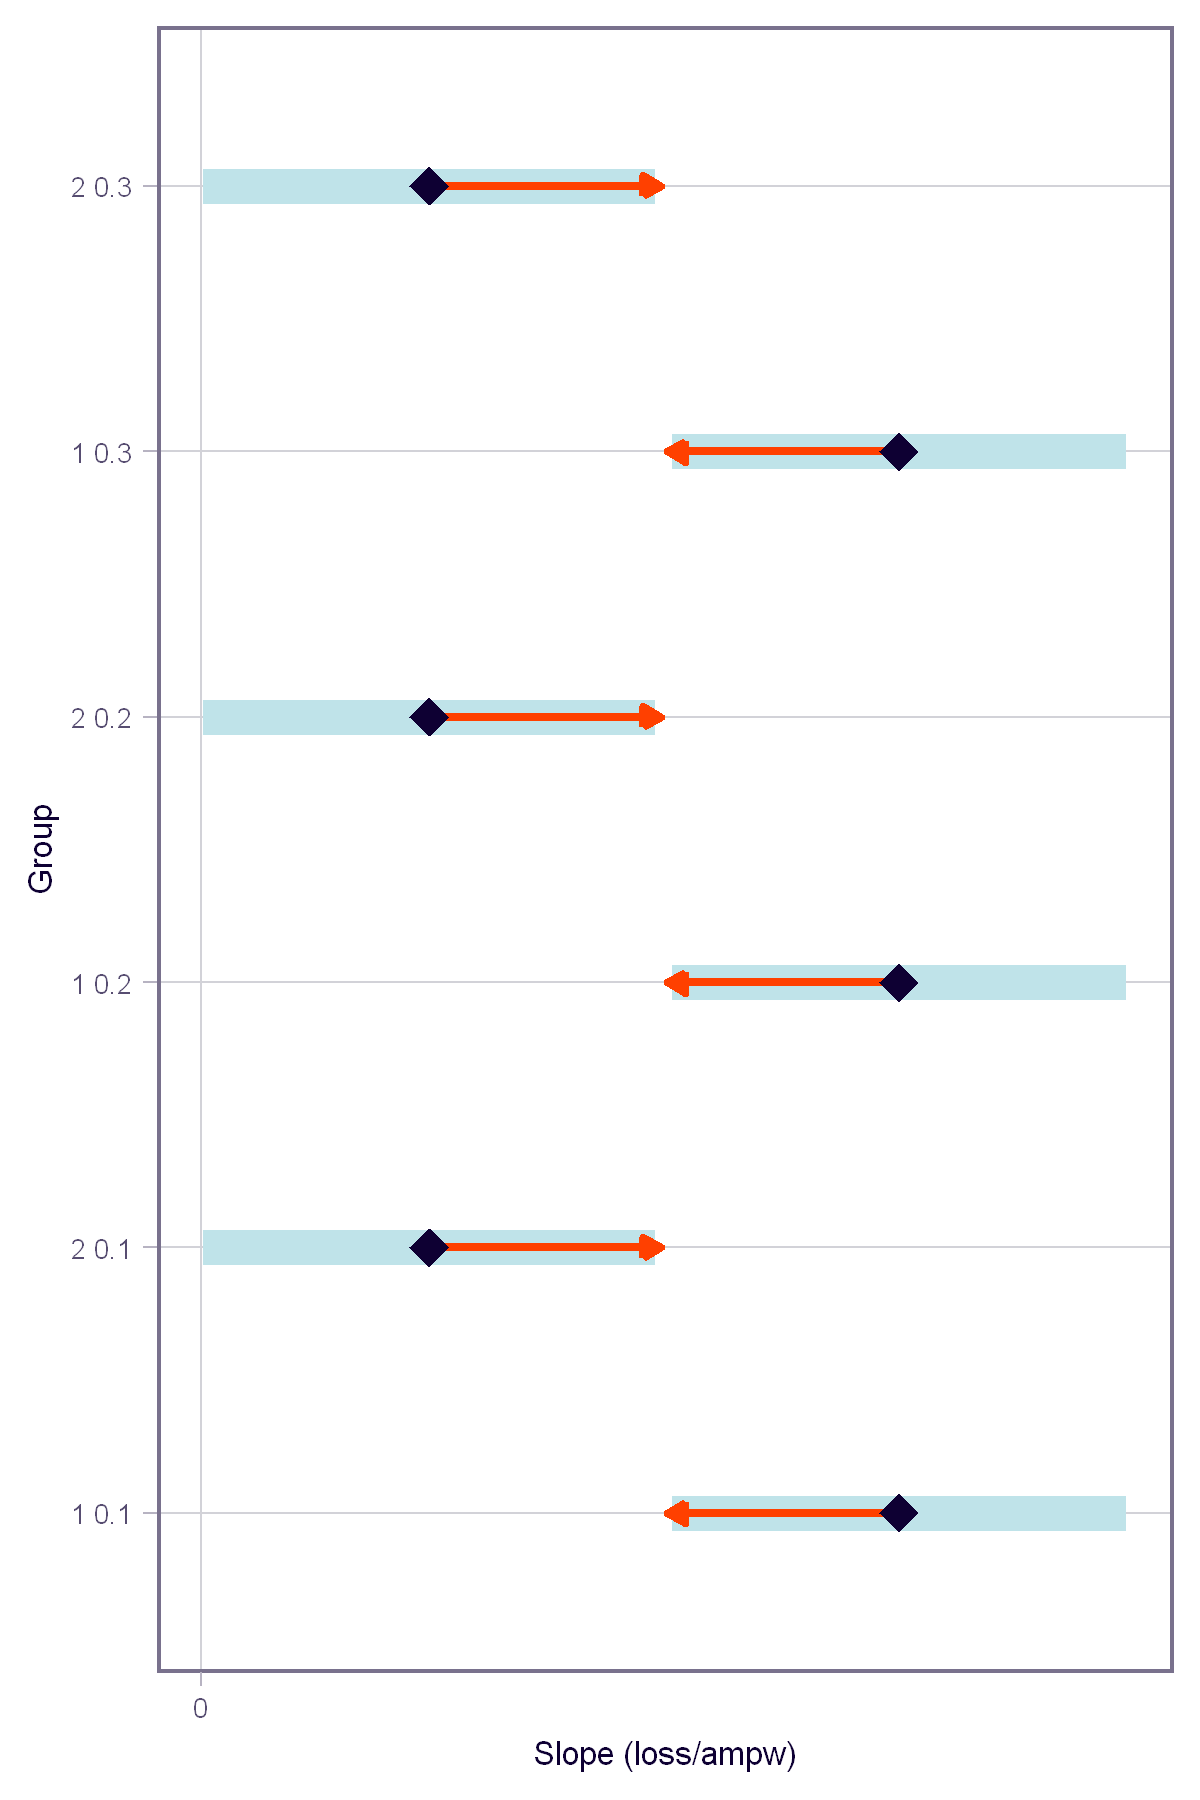

In [12]:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emtrends(
    model, 
    var = 'ampc', 
    specs = c('v1_unit', 'upper_bound')
) %>% plot(comparisons = TRUE,) +     
    labs(
        x = 'Slope (loss/ampw)',
        y = 'Group',
    ) +
    geom_point(size=0.05)+
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [13]:
fixed_effects = as.data.frame(fixef(model))
fixed_effects

,fixef(model)
,<dbl>
(Intercept),0.059919332
ampc,0.973332557
v1_unit,0.007732300
upper_bound0.2,0.006027211
upper_bound0.3,0.015079299
ampc:v1_unit,-0.391695355


In [14]:
random_effects = as.data.frame(ranef(model, condvar = TRUE))  %>% pivot_wider(
    names_from = term,
    values_from = c(condval, condsd)
)
random_effects

Warning message in ranef.merMod(model, condvar = TRUE):
"additional arguments to ranef.merMod ignored: condvar"


grpvar,grp,condval_(Intercept),condval_ampc,condsd_(Intercept),condsd_ampc
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
dlgn_unit,1_1,0.006953580,0.009013609,0.0008426358,0.028823993
dlgn_unit,1_2,-0.005523040,0.140637676,0.0008505501,0.023114953
dlgn_unit,1_3,-0.001430539,-0.149651286,0.0007692276,0.020289592
dlgn_unit,2_1,0.002028918,-0.018918001,0.0006571960,0.020625603
dlgn_unit,2_2,-0.004876867,0.188018504,0.0007757678,0.030046371
dlgn_unit,2_3,0.002847949,-0.169100503,0.0003548490,0.004239901


In [15]:
write.csv(fixed_effects, 'ampc_fixef.csv')
write.csv(random_effects, 'ampc_ranef.csv')
write.csv(intercept_pred, 'ampc_intercepts.csv')
write.csv(slope_pred, 'ampc_slopes.csv')